# PyTorch in One Hour: From Tensors to Training Neural Networks

A hands-on, runnable companion notebook covering the PyTorch essentials: tensors,
autograd, building and training neural networks, data loaders, saving models, and
moving computation onto a GPU.

> **Credit.** This notebook is adapted as a runnable tutorial from Sebastian Raschka's
> article *"PyTorch in One Hour: From Tensors to Training Neural Networks on Multiple GPUs"*
> (https://sebastianraschka.com/teaching/pytorch-1h/). The explanations here are paraphrased;
> read the original for the full prose, figures, and deeper discussion.

**What you'll work through**
1. What PyTorch is and how to install it
2. Tensors — the core data structure
3. Models as computation graphs
4. Automatic differentiation (autograd)
5. Building multilayer neural networks
6. Efficient data loaders
7. A complete training loop
8. Saving and loading models
9. Training on a GPU (single + multi-GPU notes)

Run the cells top to bottom. Each section is self-contained enough to re-run, but later
sections reuse objects defined earlier.

## 0. Setup

Install PyTorch if it isn't already available. The article pins `torch==2.4.1` for exact
reproducibility, but any recent 2.x release works for everything here. For GPU support,
generate the right command for your OS/CUDA combo at https://pytorch.org.

In [48]:
# Uncomment to install (CPU build shown). For GPU, get the command from https://pytorch.org
# %pip install torch==2.4.1
# %pip install torch  # latest

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
# Apple Silicon users can also check Metal (MPS):
print("MPS available:", getattr(torch.backends, "mps", None) is not None
      and torch.backends.mps.is_available())

PyTorch version: 2.5.1
CUDA available: False
MPS available: True


## 1. What is PyTorch

PyTorch is an open-source, Python-based deep learning library and has been the dominant
framework in research for years. It's popular because it pairs an approachable, NumPy-like
interface with the flexibility to drop down to low-level control when you need it.

It helps to think of PyTorch as **three components working together**:

1. **A tensor library** — array programming like NumPy, but with seamless CPU↔GPU execution.
2. **An automatic differentiation engine (autograd)** — computes gradients for you, which is
   what makes backpropagation practical.
3. **A deep learning toolkit** — ready-made layers, loss functions, optimizers, and data
   utilities for assembling and training models.

The rest of the notebook walks through each of these with code.

**Where deep learning fits:** AI ⊃ Machine Learning ⊃ Deep Learning. Deep learning trains
*deep neural networks* (many layers) and shines on unstructured data like images, audio, and
text — which is why it underpins large language models (LLMs).

## 2. Understanding tensors

A **tensor** generalizes numbers, vectors, and matrices to any number of dimensions. The
number of dimensions is its *rank*:

- rank 0 → scalar (a single number)
- rank 1 → vector
- rank 2 → matrix
- rank 3+ → just "3D tensor", "4D tensor", and so on

Computationally, tensors are containers for multi-dimensional data. PyTorch tensors behave a
lot like NumPy arrays, with two key additions for deep learning: **autograd** (gradient
tracking) and **GPU acceleration**.

### 2.1 Creating tensors

In [49]:
import torch

# 0D tensor (scalar) from a Python int
tensor0d = torch.tensor(1)

# 1D tensor (vector) from a list
tensor1d = torch.tensor([1, 2, 3])

# 2D tensor (matrix) from a nested list
tensor2d = torch.tensor([[1, 2], [3, 4]])

# 3D tensor from a nested list
tensor3d = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print(tensor0d)
print(tensor1d)
print(tensor2d)
print(tensor3d)

tensor(1)
tensor([1, 2, 3])
tensor([[1, 2],
        [3, 4]])
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])


> **Visualization — tensor dimensionality.** Each panel below is a direct picture of the tensor created in the cell above.

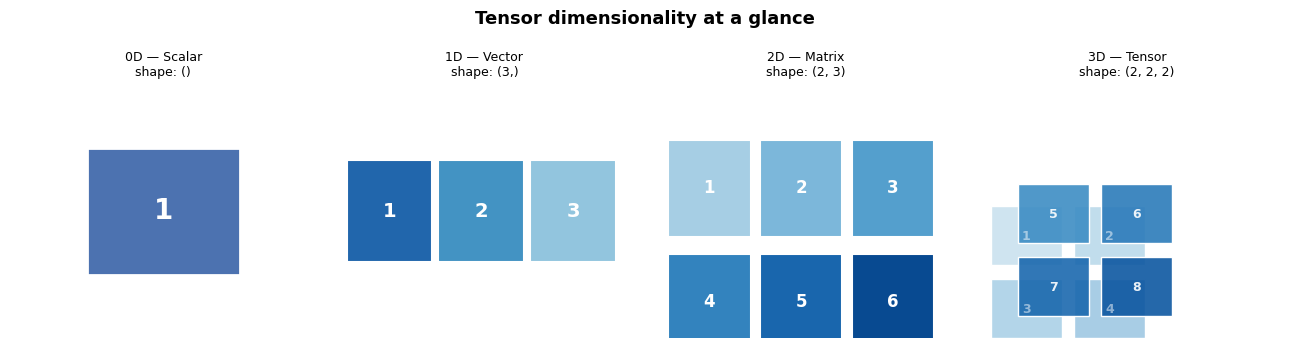

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
fig.suptitle("Tensor dimensionality at a glance", fontsize=13, fontweight="bold")

# 0-D scalar
ax = axes[0]
ax.add_patch(patches.Rectangle((0.25, 0.25), 0.5, 0.5,
             facecolor="#4C72B0", edgecolor="white", lw=2))
ax.text(0.5, 0.5, "1", ha="center", va="center",
        color="white", fontsize=20, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("0D — Scalar\nshape: ()", fontsize=9)

# 1-D vector [1, 2, 3]
ax = axes[1]
for j, (v, c) in enumerate(zip([1, 2, 3], ["#2166AC", "#4393C3", "#92C5DE"])):
    ax.add_patch(patches.Rectangle((j * 0.3 + 0.05, 0.3), 0.28, 0.4,
                 facecolor=c, edgecolor="white", lw=1.5))
    ax.text(j * 0.3 + 0.19, 0.5, str(v), ha="center", va="center",
            color="white", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("1D — Vector\nshape: (3,)", fontsize=9)

# 2-D matrix 2×3
ax = axes[2]
data2d = [[1, 2, 3], [4, 5, 6]]
for r in range(2):
    for c in range(3):
        intensity = (data2d[r][c] - 1) / 5
        col = plt.cm.Blues(0.35 + intensity * 0.55)
        ax.add_patch(patches.Rectangle(
            (c * 0.3 + 0.05, (1 - r) * 0.45 - 0.05), 0.27, 0.38,
            facecolor=col, edgecolor="white", lw=1.5))
        ax.text(c * 0.3 + 0.185, (1 - r) * 0.45 + 0.14, str(data2d[r][c]),
                ha="center", va="center", color="white", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("2D — Matrix\nshape: (2, 3)", fontsize=9)

# 3-D tensor (two stacked slabs)
ax = axes[3]
slabs = [[[1, 2], [3, 4]], [[5, 6], [7, 8]]]
for d, (ox, oy) in enumerate([(0.0, 0.0), (0.11, 0.11)]):
    alpha = 0.5 + d * 0.4
    for r in range(2):
        for c in range(2):
            val = slabs[d][r][c]
            col = list(plt.cm.Blues(0.30 + (val / 8) * 0.55))
            col[3] = alpha
            ax.add_patch(patches.Rectangle(
                (c * 0.34 + 0.07 + ox, (1 - r) * 0.36 + ox), 0.29, 0.29,
                facecolor=col, edgecolor="white", lw=1))
            ax.text(c * 0.34 + 0.215 + ox, (1 - r) * 0.36 + 0.14 + ox, str(val),
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold", alpha=alpha)
ax.set_xlim(0, 1.25); ax.set_ylim(0, 1.25); ax.axis("off")
ax.set_title("3D — Tensor\nshape: (2, 2, 2)", fontsize=9)

plt.tight_layout()
plt.show()


### 2.2 Tensor data types

The element type matters for both precision and speed. A couple of defaults to remember:

- Python **ints** → `torch.int64`
- Python **floats** → `torch.float32` (not 64)

`float32` is the deep learning workhorse: enough precision for most tasks, less memory than
`float64`, and GPUs are optimized for it. Convert types with `.to(...)`.

In [51]:
tensor1d = torch.tensor([1, 2, 3])
print("int tensor dtype:  ", tensor1d.dtype)

floatvec = torch.tensor([1.0, 2.0, 3.0])
print("float tensor dtype:", floatvec.dtype)

# change precision explicitly
floatvec = tensor1d.to(torch.float32)
print("after .to(float32):", floatvec.dtype)

int tensor dtype:   torch.int64
float tensor dtype: torch.float32
after .to(float32): torch.float32


### 2.3 Common tensor operations

A small set of operations covers most day-to-day needs: inspecting `.shape`, reshaping with
`.reshape`/`.view`, transposing with `.T`, and matrix multiplication with `.matmul` or the
`@` operator.

> `.reshape` and `.view` do the same thing here; `.view` is the more idiomatic PyTorch call.
> PyTorch often gives you both a NumPy-style and a Torch-style name for the same operation.

In [52]:
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])
print("tensor:\n", tensor2d)
print("shape:", tensor2d.shape)          # torch.Size([2, 3]) -> 2 rows, 3 cols

print("\nreshape(3, 2):\n", tensor2d.reshape(3, 2))
print("\nview(3, 2):\n", tensor2d.view(3, 2))

print("\ntranspose (.T):\n", tensor2d.T)

# matrix multiplication: (2x3) @ (3x2) -> (2x2)
print("\nmatmul:\n", tensor2d.matmul(tensor2d.T))
print("\n@ operator:\n", tensor2d @ tensor2d.T)

tensor:
 tensor([[1, 2, 3],
        [4, 5, 6]])
shape: torch.Size([2, 3])

reshape(3, 2):
 tensor([[1, 2],
        [3, 4],
        [5, 6]])

view(3, 2):
 tensor([[1, 2],
        [3, 4],
        [5, 6]])

transpose (.T):
 tensor([[1, 4],
        [2, 5],
        [3, 6]])

matmul:
 tensor([[14, 32],
        [32, 77]])

@ operator:
 tensor([[14, 32],
        [32, 77]])


## 3. Seeing models as computation graphs

A **computation graph** is a directed graph that records the sequence of operations used to
produce an output. PyTorch builds one automatically in the background, and it's exactly what
lets autograd compute gradients for backpropagation later.

Below is the forward pass of a tiny logistic regression classifier (a single-layer network):
multiply input by a weight, add a bias, squash with a sigmoid, then compare to the true label
with a loss. Don't worry if the details are unfamiliar — the point is that this is a *chain of
operations* PyTorch can track.

In [53]:
import torch.nn.functional as F

y  = torch.tensor([1.0])  # true label
x1 = torch.tensor([1.1])  # input feature
w1 = torch.tensor([2.2])  # weight
b  = torch.tensor([0.0])  # bias

z = x1 * w1 + b           # net input
a = torch.sigmoid(z)      # activation / output

loss = F.binary_cross_entropy(a, y)
print("loss:", loss)

loss: tensor(0.0852)


> **Visualization — computation graph.** Every Python operation above creates a node in this directed graph. During `.backward()` PyTorch walks the graph right-to-left, applying the chain rule at each node to accumulate gradients.

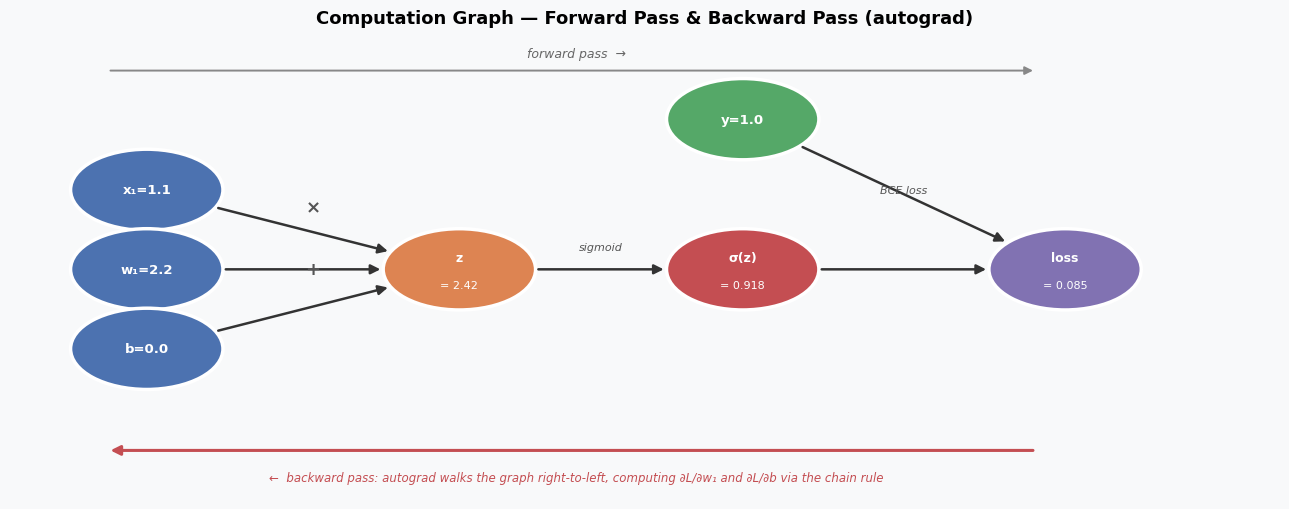

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.2); ax.axis("off")
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")
ax.set_title("Computation Graph — Forward Pass & Backward Pass (autograd)",
             fontsize=13, fontweight="bold", pad=12)

# ── helpers ──────────────────────────────────────────────────────────────────
def ellipse_edge(cx, cy, tx, ty, rx=0.78, ry=0.46):
    """Return the point on the ellipse boundary in the direction of (tx,ty)."""
    dx, dy = tx - cx, ty - cy
    dist = np.hypot(dx, dy)
    if dist == 0:
        return cx, cy
    # parametric: point = center + t*(dx,dy); on ellipse when (t*dx/rx)^2+(t*dy/ry)^2=1
    t = 1.0 / np.sqrt((dx / rx) ** 2 + (dy / ry) ** 2)
    return cx + t * dx, cy + t * dy

def draw_node(ax, x, y, line1, line2="", color="#4C72B0", rx=0.78, ry=0.46):
    e = mpatches.Ellipse((x, y), rx * 2, ry * 2,
                         facecolor=color, edgecolor="white", lw=2.5, zorder=3)
    ax.add_patch(e)
    if line2:
        ax.text(x, y + 0.13, line1, ha="center", va="center",
                fontsize=9, color="white", fontweight="bold", zorder=4)
        ax.text(x, y - 0.18, line2, ha="center", va="center",
                fontsize=8, color="white", zorder=4)
    else:
        ax.text(x, y, line1, ha="center", va="center",
                fontsize=9.5, color="white", fontweight="bold", zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, color="#333", lw=1.8, rx=0.78, ry=0.46):
    sx, sy = ellipse_edge(x1, y1, x2, y2, rx, ry)
    ex, ey = ellipse_edge(x2, y2, x1, y1, rx, ry)
    ax.annotate("", xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14))

# ── node positions ────────────────────────────────────────────────────────────
# inputs (left column), ops (middle), output (right)
#   y=1.0  ───────────────────────────────────────────────> loss
#   x₁=1.1 ──┐
#   w₁=2.2 ──┤──> z=2.42 ──> σ(z)=0.918 ──> loss=0.085
#   b=0.0  ──┘

PX = dict(x1=1.4, z=4.6, sig=7.5, loss=10.8)
PY = dict(top=4.3, mid=2.6, b=0.9)

nodes = {
    "x1":   (PX["x1"], 3.5,  "x₁=1.1",       "",         "#4C72B0"),
    "w1":   (PX["x1"], 2.6,  "w₁=2.2",        "",         "#4C72B0"),
    "b":    (PX["x1"], 1.7,  "b=0.0",          "",         "#4C72B0"),
    "y":    (PX["sig"], 4.3, "y=1.0",          "",         "#55A868"),
    "z":    (PX["z"],  2.6,  "z",              "= 2.42",   "#DD8452"),
    "sig":  (PX["sig"],2.6,  "σ(z)",           "= 0.918",  "#C44E52"),
    "loss": (PX["loss"],2.6, "loss",           "= 0.085",  "#8172B2"),
}

for key, (x, y, l1, l2, col) in nodes.items():
    draw_node(ax, x, y, l1, l2, col)

# ── forward-pass arrows ───────────────────────────────────────────────────────
nx = {k: v[:2] for k, v in nodes.items()}   # name -> (x, y)

for src, dst in [("x1","z"), ("w1","z"), ("b","z"),
                 ("z","sig"), ("sig","loss"), ("y","loss")]:
    draw_arrow(ax, *nx[src], *nx[dst])

# ── operation labels (on the arrows, not floating) ────────────────────────────
# "× then +" labels sit on the fan of arrows going into z
ax.text(3.1, 3.3,  "×", fontsize=13, color="#555", ha="center", va="center", fontweight="bold")
ax.text(3.1, 2.6,  "+", fontsize=13, color="#555", ha="center", va="center", fontweight="bold")
ax.text(6.05, 2.85, "sigmoid", fontsize=8, color="#555",
        ha="center", va="center", style="italic")
ax.text(9.15, 3.5,  "BCE loss", fontsize=8, color="#555",
        ha="center", va="center", style="italic")

# ── section labels ────────────────────────────────────────────────────────────
ax.annotate("", xy=(10.5, 4.85), xytext=(1.0, 4.85),
            arrowprops=dict(arrowstyle="-|>", color="#888", lw=1.4, mutation_scale=12))
ax.text(5.8, 5.0, "forward pass  →", ha="center", fontsize=9, color="#666", style="italic")

# ── backward-pass arrow (right-to-left, below the graph) ─────────────────────
ax.annotate("", xy=(1.0, 0.55), xytext=(10.5, 0.55),
            arrowprops=dict(arrowstyle="-|>", color="#C44E52", lw=2.2, mutation_scale=14))
ax.text(5.8, 0.2,
        "←  backward pass: autograd walks the graph right-to-left, "
        "computing ∂L/∂w₁ and ∂L/∂b via the chain rule",
        ha="center", fontsize=8.5, color="#C44E52", style="italic")

plt.tight_layout()
plt.show()


## 4. Automatic differentiation made easy

Training a network means nudging its parameters to reduce the loss, and that requires
**gradients** of the loss with respect to each parameter. Backpropagation is essentially the
calculus chain rule applied across the computation graph, from the loss backward to the inputs.

PyTorch does this for you. Mark the tensors you want gradients for with
`requires_grad=True`, and autograd tracks every operation on them.

First, the explicit `grad(...)` form — handy for understanding and debugging:

In [55]:
import torch.nn.functional as F
from torch.autograd import grad

y  = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b  = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

# retain_graph=True keeps the graph alive so we can call grad twice
grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b  = grad(loss, b,  retain_graph=True)

print("dL/dw1:", grad_L_w1)
print("dL/db: ", grad_L_b)

dL/dw1: (tensor([-0.0898]),)
dL/db:  (tensor([-0.0817]),)


In practice you rarely call `grad` by hand. Instead call `.backward()` on the loss and PyTorch
populates the `.grad` attribute of every leaf tensor that needs it. **Takeaway:** you almost
never compute derivatives manually — `.backward()` handles the calculus.

In [56]:
y  = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b  = torch.tensor([0.0], requires_grad=True)

loss = F.binary_cross_entropy(torch.sigmoid(x1 * w1 + b), y)
loss.backward()

print("w1.grad:", w1.grad)
print("b.grad: ", b.grad)

w1.grad: tensor([-0.0898])
b.grad:  tensor([-0.0817])


## 5. Implementing multilayer neural networks

To build a custom network you subclass `torch.nn.Module`. The pattern is:

- **`__init__`** — define the layers (here wrapped in `nn.Sequential` so they run in order).
- **`forward`** — describe how input flows through those layers to produce outputs.

You don't write a `backward` method — autograd derives it from `forward`.

The model below is a classic multilayer perceptron (fully connected network) with two hidden
layers and ReLU activations.

In [57]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),
            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),
            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits


model = NeuralNetwork(50, 3)
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


> **Visualization — network architecture.** Circles are neurons; columns are layers. Only a subset of neurons are drawn for the large layers (indicated by "…").

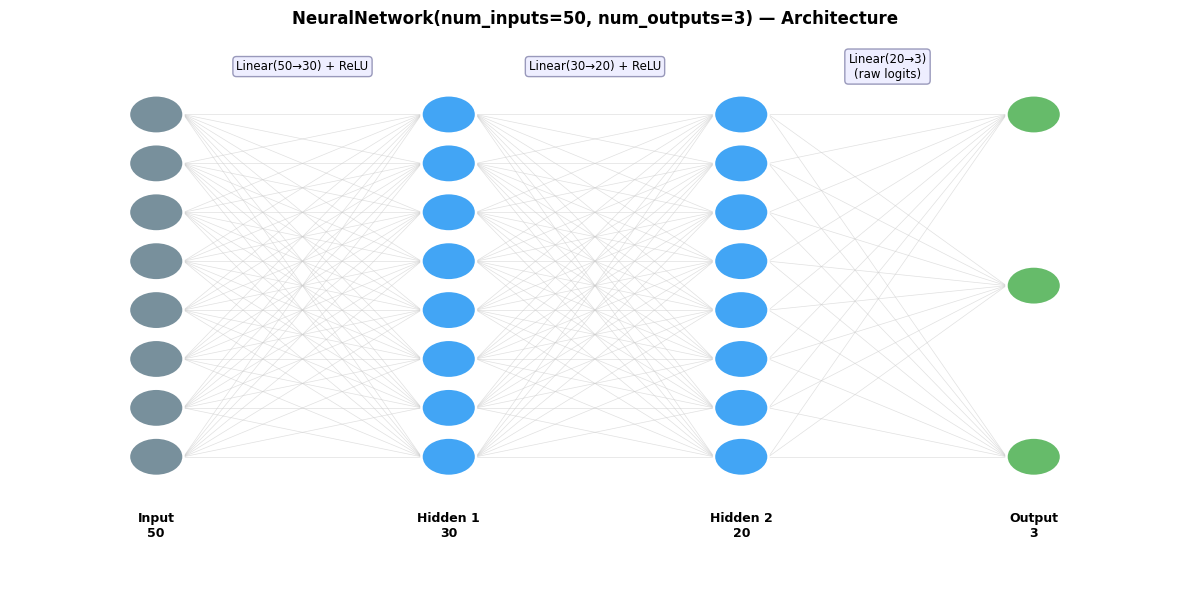

In [58]:
import matplotlib.pyplot as plt
import numpy as np

layer_info = [
    ("Input\n50", 50, 1.0, "#78909C"),
    ("Hidden 1\n30",  30, 4.0, "#42A5F5"),
    ("Hidden 2\n20",  20, 7.0, "#42A5F5"),
    ("Output\n3",      3, 10.0, "#66BB6A"),
]
MAX_SHOW = 8          # max neuron circles drawn per layer
Y_SPAN   = 5.0        # total vertical span for neurons

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.5, 11.5); ax.set_ylim(-1.5, 6.5); ax.axis("off")
ax.set_title("NeuralNetwork(num_inputs=50, num_outputs=3) — Architecture",
             fontsize=12, fontweight="bold")

neuron_ys = {}   # store y-positions of first/last neuron per layer for edges

for label, size, x, color in layer_info:
    shown = min(size, MAX_SHOW)
    spacing = Y_SPAN / max(shown - 1, 1)
    y0 = (Y_SPAN - spacing * (shown - 1)) / 2 + 0.3

    ys = []
    for i in range(shown):
        y = y0 + i * spacing
        ax.add_patch(plt.Circle((x, y), 0.28,
                     facecolor=color, edgecolor="white", lw=1.8, zorder=3))
        ys.append(y)

    if size > MAX_SHOW:
        mid_y = y0 + (shown // 2) * spacing
        ax.text(x, mid_y, "…", ha="center", va="center",
                fontsize=18, color=color, fontweight="bold", zorder=4)

    ax.text(x, -0.5, label, ha="center", va="top", fontsize=9, fontweight="bold")
    neuron_ys[x] = ys

# Draw connections (sample subset to avoid clutter)
layer_xs = [info[2] for info in layer_info]
for i in range(len(layer_xs) - 1):
    x1, x2 = layer_xs[i], layer_xs[i + 1]
    for y1 in neuron_ys[x1]:
        for y2 in neuron_ys[x2]:
            ax.plot([x1 + 0.28, x2 - 0.28], [y1, y2],
                    color="#ccc", lw=0.5, zorder=1, alpha=0.6)

# Layer operation labels
op_labels = [
    (2.5, 6.0, "Linear(50→30) + ReLU"),
    (5.5, 6.0, "Linear(30→20) + ReLU"),
    (8.5, 6.0, "Linear(20→3)\n(raw logits)"),
]
for tx, ty, text in op_labels:
    ax.text(tx, ty, text, ha="center", va="center", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#EEF", edgecolor="#99B"))

plt.tight_layout()
plt.show()


### Inspecting parameters

Each `nn.Linear` layer holds a weight matrix and a bias vector, all trainable by default
(`requires_grad=True`). Count the trainable parameters like this:

In [59]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", num_params)

# weights of the first linear layer (index 0 in the Sequential)
print("First layer weight shape:", model.layers[0].weight.shape)  # [30, 50]

Total trainable parameters: 2213
First layer weight shape: torch.Size([30, 50])


Weights are initialized to small **random** numbers, so you'll see different values each run.
Random init is important — it breaks symmetry so neurons can learn different things. To make
runs reproducible, seed the generator with `torch.manual_seed`.

In [60]:
torch.manual_seed(123)
model = NeuralNetwork(50, 3)
print(model.layers[0].weight[:2])  # first two rows, now reproducible

tensor([[-0.0577,  0.0047, -0.0702,  0.0533, -0.1205,  0.1037, -0.1028, -0.1124,
         -0.0894,  0.0640, -0.0523,  0.0529, -0.1200, -0.0858, -0.0519, -0.0278,
         -0.1079,  0.0926, -0.0334,  0.0454,  0.1000,  0.0263,  0.0387,  0.1365,
         -0.0638,  0.0448, -0.0629,  0.1011,  0.1129, -0.1304,  0.1207,  0.0675,
          0.0616,  0.0582,  0.1176, -0.0187, -0.1196, -0.0406, -0.0996,  0.0093,
         -0.0264, -0.0759, -0.0129,  0.1340, -0.0112,  0.0045, -0.0221,  0.0222,
          0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  0.0546, -0.0183, -0.1314, -0.0875,  0.1207,
          0.0085, -0.1146,  0.0223,  0.1169, -0.1336, -0.0952, -0.0563,  0.0057,
         -0.0330, -0.0155, -0.1379,  0.0662,  0.1241,  0.0864, -0.1001, -0.1140,
          0.0587,  0.0032,  0.0580, -0.1382, -0.0084,  0.0997,  0.0656,  0.0052,
          0.0278, -0.0134, -0.0778, -0.0534, -0.0861,  0.1175,  0.0778,  0.0495,
         -0.1084,  0.1091,  0.0443,  0.0978, -0.0556,  0.0300,  0.1381,  0.0951,


### Forward pass and inference

Calling `model(x)` runs the forward pass. Networks usually return raw **logits** (no final
softmax) because PyTorch's classification losses fold softmax/sigmoid in for numerical
stability. For pure inference, wrap the call in `torch.no_grad()` to skip graph construction
and save memory; apply `softmax` explicitly only when you want probabilities.

In [61]:
torch.manual_seed(123)
model = NeuralNetwork(50, 3)

X = torch.rand((1, 50))         # one random 50-dim example
out = model(X)
print("logits (with grad_fn):", out)

with torch.no_grad():
    out = model(X)
print("logits (no_grad):     ", out)

with torch.no_grad():
    probas = torch.softmax(model(X), dim=1)
print("probabilities:        ", probas, "-> sum:", probas.sum().item())

logits (with grad_fn): tensor([[-0.1670,  0.1001, -0.1219]], grad_fn=<AddmmBackward0>)
logits (no_grad):      tensor([[-0.1670,  0.1001, -0.1219]])
probabilities:         tensor([[0.2983, 0.3896, 0.3121]]) -> sum: 1.0


## 6. Setting up efficient data loaders

Training iterates over data in **batches**. PyTorch splits this into two pieces:

- **`Dataset`** — knows how to fetch a single example (`__getitem__`) and how many there are
  (`__len__`).
- **`DataLoader`** — wraps a `Dataset` to handle batching, shuffling, and parallel loading.

First, a tiny toy dataset: 5 training examples with 2 features each, plus a 2-example test set.

> **Label convention:** class labels must start at 0 and go up to `num_outputs - 1`.

In [62]:
X_train = torch.tensor([
    [-1.2,  3.1],
    [-0.9,  2.9],
    [-0.5,  2.6],
    [ 2.3, -1.1],
    [ 2.7, -1.5],
])
y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [-0.8,  2.8],
    [ 2.6, -1.6],
])
y_test = torch.tensor([0, 1])

In [63]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

    def __len__(self):
        return self.labels.shape[0]


train_ds = ToyDataset(X_train, y_train)
test_ds  = ToyDataset(X_test, y_test)
print("train size:", len(train_ds), "| test size:", len(test_ds))

train size: 5 | test size: 2


Now wrap the datasets in `DataLoader`s. Note `drop_last=True` on the training loader: with 5
examples and batch size 2, the final batch would have a single example, which can destabilize
training — dropping it avoids that.

About **`num_workers`**: it controls parallel data loading. `0` loads in the main process
(fine for tiny data and notebooks). On large datasets, a value like `4` keeps the GPU fed by
prefetching batches in background processes. Inside Jupyter, keep it at `0` to avoid
multiprocessing issues.

In [64]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
)

for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x.tolist(), y.tolist())

Batch 1: [[2.299999952316284, -1.100000023841858], [-0.8999999761581421, 2.9000000953674316]] [1, 0]
Batch 2: [[-1.2000000476837158, 3.0999999046325684], [-0.5, 2.5999999046325684]] [0, 0]


## 7. A typical training loop

Now combine everything. The standard PyTorch loop, per batch, is:

1. `logits = model(features)` — forward pass
2. `loss = F.cross_entropy(logits, labels)` — compute loss (cross-entropy applies softmax internally)
3. `optimizer.zero_grad()` — **reset** old gradients (PyTorch accumulates by default)
4. `loss.backward()` — backprop to fill `.grad`
5. `optimizer.step()` — update parameters using those gradients

`model.train()` / `model.eval()` toggle training vs. inference behavior (matters for dropout,
batch norm, etc.). Our toy model has neither, but it's good habit to include them.

The **learning rate** (`lr`) and **number of epochs** are hyperparameters you tune by watching
the loss.

In [65]:
import torch.nn.functional as F

torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 20          # extended for a more informative loss curve
loss_history = []

for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        logits = model(features)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs} | last batch loss: {loss:.4f}")

model.eval()
print("Training complete.")


Epoch 05/20 | last batch loss: 0.0197
Epoch 10/20 | last batch loss: 0.0016
Epoch 15/20 | last batch loss: 0.0022
Epoch 20/20 | last batch loss: 0.0018
Training complete.


> **Visualization — loss curve.** A healthy training run shows loss decreasing and levelling off. Each point is one mini-batch update.

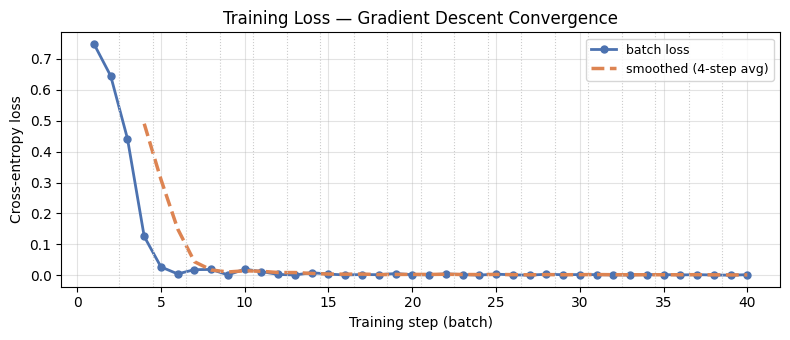

In [66]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, len(loss_history) + 1)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(steps, loss_history, marker="o", ms=5, lw=2, color="#4C72B0", label="batch loss")

# smoothed trend
if len(loss_history) >= 4:
    kernel = np.ones(4) / 4
    smoothed = np.convolve(loss_history, kernel, mode="valid")
    ax.plot(steps[len(steps) - len(smoothed):], smoothed,
            lw=2.5, color="#DD8452", linestyle="--", label="smoothed (4-step avg)")

# epoch boundary lines
batches_per_epoch = len(loss_history) // 20
for e in range(1, 20):
    ax.axvline(e * batches_per_epoch + 0.5, color="#ccc", lw=0.8, ls=":")

ax.set_xlabel("Training step (batch)")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training Loss — Gradient Descent Convergence")
ax.legend(fontsize=9); ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()


### Making predictions

After training, run the model in `eval()` mode under `no_grad()`. Convert logits to
probabilities with `softmax`, and to class labels with `argmax` (you can `argmax` the logits
directly — softmax doesn't change which class is largest).

In [67]:
model.eval()
with torch.no_grad():
    outputs = model(X_train)

torch.set_printoptions(sci_mode=False)
probas = torch.softmax(outputs, dim=1)
print("probabilities:\n", probas)

predictions = torch.argmax(probas, dim=1)
print("\npredictions:", predictions.tolist())
print("true labels:", y_train.tolist())
print("correct:", torch.sum(predictions == y_train).item(), "/", len(y_train))

probabilities:
 tensor([[    0.9998,     0.0002],
        [    0.9996,     0.0004],
        [    0.9986,     0.0014],
        [    0.0024,     0.9976],
        [    0.0009,     0.9991]])

predictions: [0, 0, 0, 1, 1]
true labels: [0, 0, 0, 1, 1]
correct: 5 / 5


### A reusable accuracy function

For real datasets you compute accuracy batch-by-batch over a loader (the whole set may not fit
in memory). This generalizes to any dataset size.

In [68]:
def compute_accuracy(model, dataloader):
    model.eval()
    correct, total = 0.0, 0
    for features, labels in dataloader:
        with torch.no_grad():
            logits = model(features)
        predictions = torch.argmax(logits, dim=1)
        correct += torch.sum(labels == predictions)
        total += len(labels)
    return (correct / total).item()


print("train accuracy:", compute_accuracy(model, train_loader))
print("test accuracy: ", compute_accuracy(model, test_loader))

train accuracy: 1.0
test accuracy:  1.0


> **Visualization — decision boundary.** The shaded regions show what class the trained model predicts at every point in feature space. The dashed line is where the model's confidence is exactly 50/50.

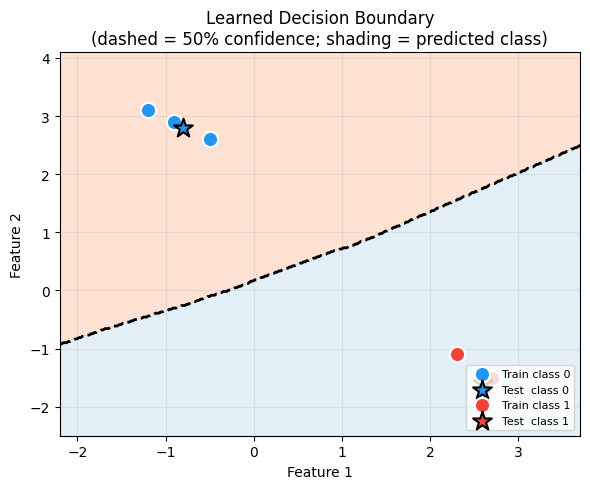

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Build a fine mesh over the feature space
x_min, x_max = X_train[:, 0].min().item() - 1.0, X_train[:, 0].max().item() + 1.0
y_min, y_max = X_train[:, 1].min().item() - 1.0, X_train[:, 1].max().item() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = torch.argmax(model(grid), dim=1).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, preds, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
ax.contour(xx, yy, preds, levels=[0.5], colors="black", linewidths=2, linestyles="--")

palette = {0: "#2196F3", 1: "#F44336"}
for cls in [0, 1]:
    mask_tr = (y_train == cls)
    ax.scatter(X_train[mask_tr, 0].numpy(), X_train[mask_tr, 1].numpy(),
               c=palette[cls], s=120, edgecolors="white", lw=1.5,
               marker="o", label=f"Train class {cls}", zorder=4)
    mask_te = (y_test == cls)
    ax.scatter(X_test[mask_te, 0].numpy(), X_test[mask_te, 1].numpy(),
               c=palette[cls], s=200, edgecolors="black", lw=1.5,
               marker="*", label=f"Test  class {cls}", zorder=5)

ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.set_title("Learned Decision Boundary\n(dashed = 50% confidence; shading = predicted class)")
ax.legend(fontsize=8, loc="lower right"); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Saving and loading models

The recommended approach saves the **`state_dict`** — a dictionary mapping each layer to its
learned weights and biases — rather than the whole Python object. To restore, recreate a model
with the *same architecture*, then load the saved parameters into it.

In [70]:
# save
torch.save(model.state_dict(), "model.pth")

# load — architecture must match the saved model exactly
restored = NeuralNetwork(2, 2)
restored.load_state_dict(torch.load("model.pth", weights_only=True))
restored.eval()

# verify it behaves identically
with torch.no_grad():
    same = torch.allclose(model(X_train), restored(X_train))
print("restored model matches original:", same)

restored model matches original: True


## 9. Optimizing training performance with GPUs

### 9.1 The device concept

In PyTorch a **device** is where a tensor lives and where its operations run (CPU, `cuda` GPU,
or Apple `mps`). The rule: **all tensors in an operation must be on the same device**. Move
tensors with `.to(device)`.

The cell below picks a GPU automatically if one is available and falls back to CPU otherwise —
the portable pattern you should use when sharing code.

In [71]:
# Portable device selection (CUDA -> MPS -> CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

tensor_1 = torch.tensor([1., 2., 3.]).to(device)
tensor_2 = torch.tensor([4., 5., 6.]).to(device)
print("sum on device:", tensor_1 + tensor_2)

Using device: mps
sum on device: tensor([5., 7., 9.], device='mps:0')


### 9.2 Single-GPU training

Moving training onto a GPU takes only **three additions** to the loop from Section 7:

1. choose a `device`,
2. move the **model** onto it (`model.to(device)`),
3. move each **batch** onto it (`features, labels = features.to(device), labels.to(device)`).

The cell uses the `device` selected above, so it runs unchanged on CPU, CUDA, or MPS.

In [72]:
torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)
model.to(device)                      # (2) model -> device
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        features, labels = features.to(device), labels.to(device)  # (3) data -> device
        logits = model(features)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train Loss: {loss:.2f}")
    model.eval()

Epoch: 001/003 | Batch 000/002 | Train Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train Loss: 0.00


On this tiny dataset a GPU won't be faster (the CPU↔GPU transfer cost dominates), but for deep
networks and LLMs the speedup is dramatic.

### 9.3 Training with multiple GPUs (DDP) — read-only

For multiple GPUs, PyTorch's **`DistributedDataParallel` (DDP)** runs one process per GPU, each
with a model copy, feeding each a different non-overlapping slice of every batch via a
`DistributedSampler`. Gradients are averaged and synchronized so the copies stay identical.
With *N* GPUs you can approach an *N×* epoch speedup (minus communication overhead).

> **Important:** DDP relies on spawning multiple processes and **does not run inside a Jupyter
> notebook**. Save the script below as `DDP-script-torchrun.py` and launch it from a terminal
> with `torchrun`. The next cell is marked `%%writefile` so running it just writes the file —
> it does not execute the training.

Launch commands (from a terminal, not the notebook):

```bash
# two GPUs
torchrun --nproc_per_node=2 DDP-script-torchrun.py

# all available GPUs
torchrun --nproc_per_node=$(nvidia-smi -L | wc -l) DDP-script-torchrun.py
```

In [73]:
%%writefile DDP-script-torchrun.py
import os
import platform
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group


def ddp_setup(rank, world_size):
    """Initialize one process group per GPU so processes can communicate."""
    if "MASTER_ADDR" not in os.environ:
        os.environ["MASTER_ADDR"] = "localhost"
    if "MASTER_PORT" not in os.environ:
        os.environ["MASTER_PORT"] = "12345"

    if platform.system() == "Windows":
        os.environ["USE_LIBUV"] = "0"            # Windows build lacks libuv
        init_process_group(backend="gloo", rank=rank, world_size=world_size)
    else:
        init_process_group(backend="nccl", rank=rank, world_size=world_size)
    torch.cuda.set_device(rank)


class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features, self.labels = X, y

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

    def __len__(self):
        return self.labels.shape[0]


class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(num_inputs, 30), torch.nn.ReLU(),
            torch.nn.Linear(30, 20),         torch.nn.ReLU(),
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        return self.layers(x)


def prepare_dataset():
    X_train = torch.tensor([[-1.2, 3.1], [-0.9, 2.9], [-0.5, 2.6],
                            [2.3, -1.1], [2.7, -1.5]])
    y_train = torch.tensor([0, 0, 0, 1, 1])
    X_test  = torch.tensor([[-0.8, 2.8], [2.6, -1.6]])
    y_test  = torch.tensor([0, 1])

    # Uncomment to grow the dataset enough for up to 8 GPUs:
    # factor = 4
    # X_train = torch.cat([X_train + torch.randn_like(X_train) * 0.1 for _ in range(factor)])
    # y_train = y_train.repeat(factor)
    # X_test  = torch.cat([X_test  + torch.randn_like(X_test)  * 0.1 for _ in range(factor)])
    # y_test  = y_test.repeat(factor)

    train_ds, test_ds = ToyDataset(X_train, y_train), ToyDataset(X_test, y_test)
    train_loader = DataLoader(
        dataset=train_ds, batch_size=2, shuffle=False,  # sampler handles shuffling
        pin_memory=True, drop_last=True,
        sampler=DistributedSampler(train_ds),
    )
    test_loader = DataLoader(dataset=test_ds, batch_size=2, shuffle=False)
    return train_loader, test_loader


def compute_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0.0, 0
    for features, labels in dataloader:
        features, labels = features.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(features)
        predictions = torch.argmax(logits, dim=1)
        correct += torch.sum(labels == predictions)
        total += len(labels)
    return (correct / total).item()


def main(rank, world_size, num_epochs):
    ddp_setup(rank, world_size)

    train_loader, test_loader = prepare_dataset()
    model = NeuralNetwork(num_inputs=2, num_outputs=2)
    model.to(rank)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
    model = DDP(model, device_ids=[rank])   # core model accessible as model.module

    for epoch in range(num_epochs):
        train_loader.sampler.set_epoch(epoch)  # different shuffle each epoch
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(rank), labels.to(rank)
            loss = F.cross_entropy(model(features), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            print(f"[GPU{rank}] Epoch: {epoch+1:03d}/{num_epochs:03d}"
                  f" | Batchsize {labels.shape[0]:03d} | Train Loss: {loss:.2f}")

    model.eval()
    try:
        print(f"[GPU{rank}] Training accuracy", compute_accuracy(model, train_loader, rank))
        print(f"[GPU{rank}] Test accuracy",     compute_accuracy(model, test_loader, rank))
    except ZeroDivisionError as e:
        raise ZeroDivisionError(
            f"{e}\n\nThis script is designed for 2 GPUs. Run it with:\n"
            "torchrun --nproc_per_node=2 DDP-script-torchrun.py\n"
            f"Or for {torch.cuda.device_count()} GPUs, uncomment the dataset-growth lines."
        )

    destroy_process_group()


if __name__ == "__main__":
    world_size = int(os.environ.get("WORLD_SIZE", 1))
    if "LOCAL_RANK" in os.environ:
        rank = int(os.environ["LOCAL_RANK"])
    elif "RANK" in os.environ:
        rank = int(os.environ["RANK"])
    else:
        rank = 0

    if rank == 0:
        print("PyTorch version:", torch.__version__)
        print("CUDA available:", torch.cuda.is_available())
        print("Number of GPUs available:", torch.cuda.device_count())

    torch.manual_seed(123)
    main(rank, world_size, num_epochs=3)

Overwriting DDP-script-torchrun.py


## Summary

- **PyTorch = tensor library + autograd + deep learning toolkit.**
- **Tensors** are NumPy-like arrays (scalars → matrices → higher-D) with GPU support and
  gradient tracking.
- **Autograd** computes gradients automatically via `.backward()` — no manual calculus.
- Build models by subclassing `nn.Module`, defining layers in `__init__` and data flow in
  `forward`.
- **`Dataset` + `DataLoader`** give you clean, batched, shuffled, parallel data pipelines.
- The training loop is always: forward → loss → `zero_grad` → `backward` → `step`.
- Save/restore with the **`state_dict`**.
- Moving to a **single GPU** is three `.to(device)` lines; for **multiple GPUs** use **DDP**
  (run as a `torchrun` script, not in a notebook).

### Further reading
- *Machine Learning with PyTorch and Scikit-Learn* (2022) — Raschka, Liu, Mirjalili.
- *Deep Learning with PyTorch* (2021) — Stevens, Antiga, Viehmann.
- DDP API docs: https://pytorch.org/docs/stable/generated/torch.nn.parallel.DistributedDataParallel.html
- FSDP (for models too big for one GPU): https://pytorch.org/blog/introducing-pytorch-fully-sharded-data-parallel-api/
- Original article: https://sebastianraschka.com/teaching/pytorch-1h/